In [3]:
pip install yfinance


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



  Using cached yfinance-1.4.1-py2.py3-none-any.whl (137 kB)
  Using cached peewee-4.0.6-py3-none-any.whl (146 kB)
  Using cached curl_cffi-0.15.0-cp310-abi3-win_amd64.whl (1.7 MB)
  Using cached multitasking-0.0.13-py3-none-any.whl (16 kB)
  Using cached websockets-16.0-cp310-cp310-win_amd64.whl (178 kB)
  Using cached rich-15.0.0-py3-none-any.whl (310 kB)
  Using cached markdown_it_py-4.2.0-py3-none-any.whl (91 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl (10.0 kB)


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [5]:
import requests
import json
from datetime import datetime, timedelta


In [6]:
tesla = yf.download("TSLA", start="2023-01-01", end="2023-12-31")
print(tesla.shape)
print(tesla.head())
print(tesla.columns.tolist())

[*********************100%***********************]  1 of 1 completed

(250, 5)
Price            Close        High         Low        Open     Volume
Ticker            TSLA        TSLA        TSLA        TSLA       TSLA
Date                                                                 
2023-01-03  108.099998  118.800003  104.639999  118.470001  231402800
2023-01-04  113.639999  114.589996  107.519997  109.110001  180389000
2023-01-05  110.339996  111.750000  107.160004  110.510002  157986300
2023-01-06  113.059998  114.389999  101.809998  103.000000  220911100
2023-01-09  119.769997  123.519997  117.110001  118.959999  190284000
[('Close', 'TSLA'), ('High', 'TSLA'), ('Low', 'TSLA'), ('Open', 'TSLA'), ('Volume', 'TSLA')]


In [7]:
tesla = tesla[["Open","High","Low","Close","Volume"]]
tesla = tesla.reset_index()
tesla.columns = ["Date","Open","High","Low","Close","Volume"]

In [8]:
tesla["Daily_Return"] = tesla["Close"].pct_change() * 100

In [9]:
tesla["Direction"] = tesla["Daily_Return"].apply(
    lambda x: "Up" if x > 0 else "Down")

In [10]:
tesla.shape

(250, 8)

In [11]:
tesla.head(10)

,Date,Open,High,Low,Close,Volume,Daily_Return,Direction
0,2023-01-03,118.470001,118.800003,104.639999,108.099998,231402800,NaN,Down
1,2023-01-04,109.110001,114.589996,107.519997,113.639999,180389000,5.124885,Up
2,2023-01-05,110.510002,111.750000,107.160004,110.339996,157986300,-2.903910,Down
3,2023-01-06,103.000000,114.389999,101.809998,113.059998,220911100,2.465109,Up
4,2023-01-09,118.959999,123.519997,117.110001,119.769997,190284000,5.934901,Up
5,2023-01-10,121.070000,122.760002,114.919998,118.849998,167642500,-0.768137,Down
6,2023-01-11,122.089996,125.949997,120.510002,123.220001,183810800,3.676906,Up
7,2023-01-12,122.559998,124.129997,117.000000,123.559998,169400900,0.275926,Up
8,2023-01-13,116.550003,122.629997,115.599998,122.400002,180714100,-0.938812,Down
9,2023-01-17,125.699997,131.699997,125.019997,131.490005,186477000,7.426474,Up


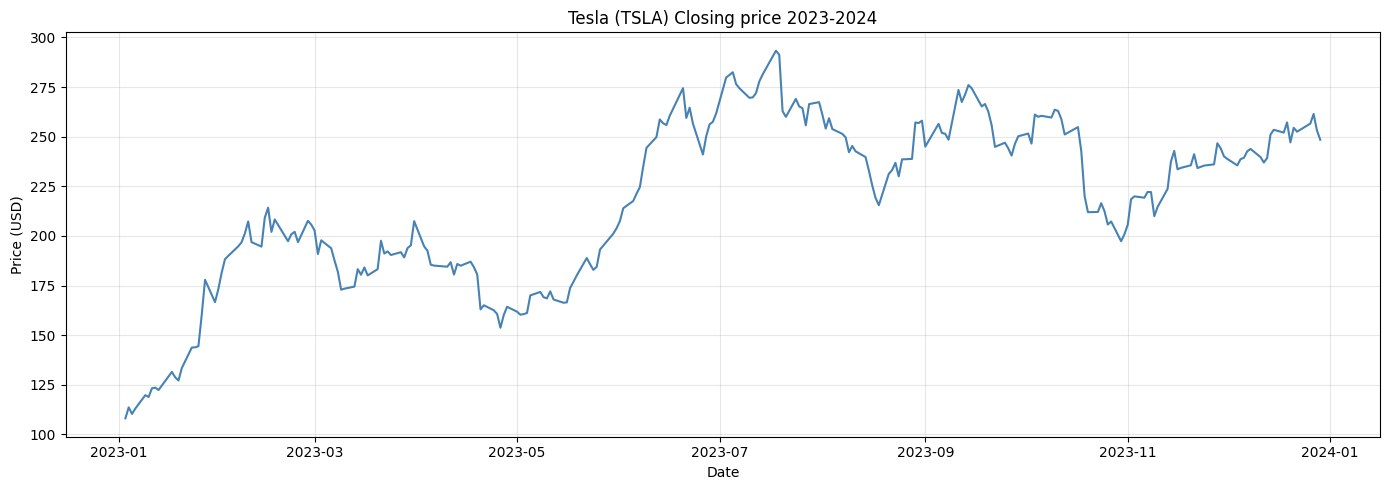

In [12]:
plt.figure(figsize=(14,5))
plt.plot(tesla["Date"], tesla["Close"], color="steelblue", linewidth=1.5)
plt.title("Tesla (TSLA) Closing price 2023-2024")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

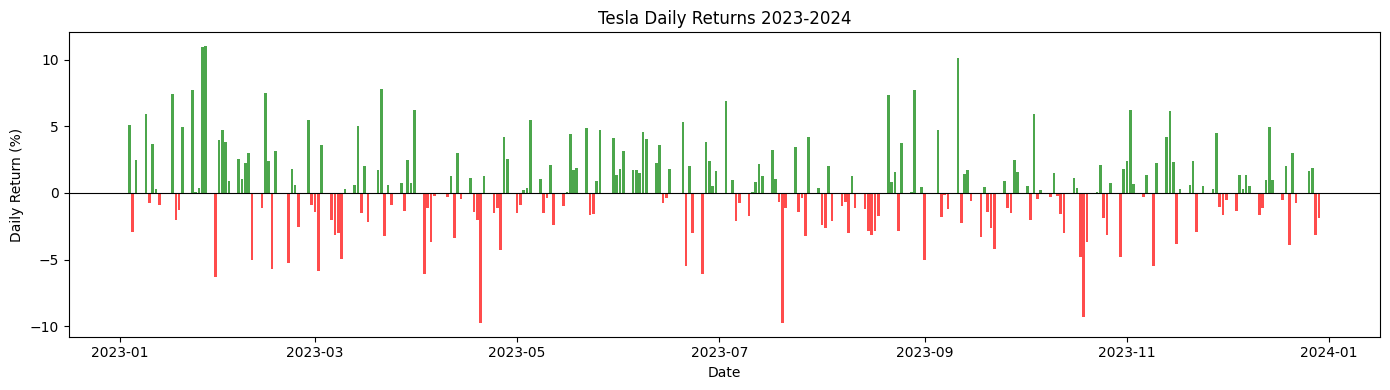

In [13]:
plt.figure(figsize=(14,4))
plt.bar(tesla["Date"], tesla["Daily_Return"],color=tesla["Direction"].map({"Up":"green","Down":"red"}),alpha=0.7)
plt.title("Tesla Daily Returns 2023-2024")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")
plt.axhline(y=0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

In [14]:
tesla.to_csv("../data/tesla_stock.csv", index=False)
print("Stock data saved!")

Stock data saved!


In [15]:
print(f"Total trading days: {len(tesla)}")
print(f"Average daily return: {tesla['Daily_Return'].mean():.2f}%")
print(f"Most volatile day: {tesla['Daily_Return'].abs().max():.2f}%")

Total trading days: 250
Average daily return: 0.39%
Most volatile day: 11.00%


In [16]:
import pandas as pd
import os

# Check what files are in data folder
import os
for f in os.listdir("../data"):
    print(f)

.ipynb_checkpoints
stock_tweets.csv
stock_yfinance_data.csv
tesla_stock.csv
tesla_stock_clean.csv
tesla_tweets.csv


In [17]:
# Load tweets data
tweets = pd.read_csv("../data/stock_tweets.csv")
print(f"Tweets shape: {tweets.shape}")
print(tweets.head())
print(f"\nColumns: {tweets.columns.tolist()}")

# Check unique stocks available
print(f"\nUnique stocks: {tweets['Stock Name'].unique()}")

Tweets shape: (80793, 4)
                        Date  \
0  2022-09-29 23:41:16+00:00   
1  2022-09-29 23:24:43+00:00   
2  2022-09-29 23:18:08+00:00   
3  2022-09-29 22:40:07+00:00   
4  2022-09-29 22:27:05+00:00   

                                               Tweet Stock Name Company Name  
0  Mainstream media has done an amazing job at br...       TSLA  Tesla, Inc.  
1  Tesla delivery estimates are at around 364k fr...       TSLA  Tesla, Inc.  
2  3/ Even if I include 63.0M unvested RSUs as of...       TSLA  Tesla, Inc.  
3  @RealDanODowd @WholeMarsBlog @Tesla Hahaha why...       TSLA  Tesla, Inc.  
4  @RealDanODowd @Tesla Stop trying to kill kids,...       TSLA  Tesla, Inc.  

Columns: ['Date', 'Tweet', 'Stock Name', 'Company Name']

Unique stocks: ['TSLA' 'MSFT' 'PG' 'META' 'AMZN' 'GOOG' 'AMD' 'AAPL' 'NFLX' 'TSM' 'KO'
 'F' 'COST' 'DIS' 'VZ' 'CRM' 'INTC' 'BA' 'BX' 'NOC' 'PYPL' 'ENPH' 'NIO'
 'ZS' 'XPEV']


In [18]:
# Filter Tesla tweets only
tesla_tweets = tweets[tweets["Stock Name"] == "TSLA"].copy()
print(f"Tesla tweets: {len(tesla_tweets)}")

# Clean the date column — remove timezone info
tesla_tweets["Date"] = pd.to_datetime(tesla_tweets["Date"]).dt.date
tesla_tweets["Date"] = pd.to_datetime(tesla_tweets["Date"])

# Check date range
print(f"Date range: {tesla_tweets['Date'].min()} to {tesla_tweets['Date'].max()}")
print(tesla_tweets.head())

Tesla tweets: 37422
Date range: 2021-09-30 00:00:00 to 2022-09-29 00:00:00
        Date                                              Tweet Stock Name  \
0 2022-09-29  Mainstream media has done an amazing job at br...       TSLA   
1 2022-09-29  Tesla delivery estimates are at around 364k fr...       TSLA   
2 2022-09-29  3/ Even if I include 63.0M unvested RSUs as of...       TSLA   
3 2022-09-29  @RealDanODowd @WholeMarsBlog @Tesla Hahaha why...       TSLA   
4 2022-09-29  @RealDanODowd @Tesla Stop trying to kill kids,...       TSLA   

  Company Name  
0  Tesla, Inc.  
1  Tesla, Inc.  
2  Tesla, Inc.  
3  Tesla, Inc.  
4  Tesla, Inc.  


In [25]:
# Check unique stocks
print(f"Unique stocks: {stock['Stock Name'].unique()}")

# Filter Tesla stock only
tesla_stock = stock[stock["Stock Name"] == "TSLA"].copy()
tesla_stock["Date"] = pd.to_datetime(tesla_stock["Date"])
print(f"\nTesla stock rows: {len(tesla_stock)}")
print(tesla_stock.head())

NameError: name 'stock' is not defined

In [21]:
# Load stock price data
stock = pd.read_csv("../data/stock_yfinance_data.csv")
print(f"\nStock data shape: {stock.shape}")
print(f"Columns: {stock.columns.tolist()}")
print(f"Unique stocks: {stock['Stock Name'].unique()}")


Stock data shape: (6300, 8)
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Stock Name']
Unique stocks: ['TSLA' 'MSFT' 'PG' 'META' 'AMZN' 'GOOG' 'AMD' 'AAPL' 'NFLX' 'TSM' 'KO'
 'F' 'COST' 'DIS' 'VZ' 'CRM' 'INTC' 'BA' 'BX' 'NOC' 'PYPL' 'ENPH' 'NIO'
 'ZS' 'XPEV']


In [26]:
# Filter Tesla stock only
tesla_stock = stock[stock["Stock Name"] == "TSLA"].copy()
tesla_stock["Date"] = pd.to_datetime(tesla_stock["Date"])
print(f"\nTesla stock rows: {len(tesla_stock)}")
print(tesla_stock.head())

NameError: name 'stock' is not defined

In [23]:
# Filter Tesla tweets only
tesla_tweets = tweets[tweets["Stock Name"] == "TSLA"].copy()
print(f"Tesla tweets: {len(tesla_tweets)}")

# Clean the date column — remove timezone info
tesla_tweets["Date"] = pd.to_datetime(tesla_tweets["Date"]).dt.date
tesla_tweets["Date"] = pd.to_datetime(tesla_tweets["Date"])

# Check date range
print(f"Date range: {tesla_tweets['Date'].min()} to {tesla_tweets['Date'].max()}")
print(tesla_tweets.head())

Tesla tweets: 37422
Date range: 2021-09-30 00:00:00 to 2022-09-29 00:00:00
        Date                                              Tweet Stock Name  \
0 2022-09-29  Mainstream media has done an amazing job at br...       TSLA   
1 2022-09-29  Tesla delivery estimates are at around 364k fr...       TSLA   
2 2022-09-29  3/ Even if I include 63.0M unvested RSUs as of...       TSLA   
3 2022-09-29  @RealDanODowd @WholeMarsBlog @Tesla Hahaha why...       TSLA   
4 2022-09-29  @RealDanODowd @Tesla Stop trying to kill kids,...       TSLA   

  Company Name  
0  Tesla, Inc.  
1  Tesla, Inc.  
2  Tesla, Inc.  
3  Tesla, Inc.  
4  Tesla, Inc.  


In [24]:
tesla_tweets.to_csv("../data/tesla_tweets.csv", index=False)
tesla_stock.to_csv("../data/tesla_stock_clean.csv", index=False)
print("Both saved!")
print(f"Tesla tweets: {len(tesla_tweets)}")
print(f"Tesla stock rows: {len(tesla_stock)}")

NameError: name 'tesla_stock' is not defined

In [27]:
import pandas as pd

# Reload both datasets
tweets = pd.read_csv("../data/stock_tweets.csv")
stock  = pd.read_csv("../data/stock_yfinance_data.csv")

# Filter Tesla only
tesla_tweets = tweets[tweets["Stock Name"] == "TSLA"].copy()
tesla_tweets["Date"] = pd.to_datetime(tesla_tweets["Date"]).dt.date
tesla_tweets["Date"] = pd.to_datetime(tesla_tweets["Date"])

tesla_stock = stock[stock["Stock Name"] == "TSLA"].copy()
tesla_stock["Date"] = pd.to_datetime(tesla_stock["Date"])

print(f"Tesla tweets: {len(tesla_tweets)}")
print(f"Tesla stock rows: {len(tesla_stock)}")
print("Ready!")

Tesla tweets: 37422
Tesla stock rows: 252
Ready!


In [28]:
tesla_tweets.to_csv("../data/tesla_tweets.csv", index=False)
tesla_stock.to_csv("../data/tesla_stock_clean.csv", index=False)
print("Both saved!")

Both saved!
